<a href="https://colab.research.google.com/github/imrohitm25-maker/assignment/blob/main/Zepto_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Importing The Dataset

In [ ]:
df=pd.read_csv("/content/zepto_sales.csv")
df1=pd.read_csv("/content/zepto_products.csv")

**Exploring the Datasets**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220220 entries, 0 to 220219
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            220220 non-null  int64  
 1   order_date          220220 non-null  object 
 2   product_id          220220 non-null  int64  
 3   quantity            220220 non-null  int64  
 4   city                219118 non-null  object 
 5   delivery_status     219118 non-null  object 
 6   customer_id         220220 non-null  int64  
 7   delivery_time_mins  215817 non-null  float64
 8   total_amount        220220 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 15.1+ MB


In [ ]:
df.describe()

,order_id,product_id,quantity,customer_id,delivery_time_mins,total_amount
count,91904.000000,91904.000000,91904.000000,91903.000000,90042.000000,91903.000000
mean,152371.507889,119.250914,1.547441,60055.095927,26.022334,301.987905
std,30150.622800,12.108751,1.000142,5790.915638,10.687148,323.354784
min,100002.000000,101.000000,1.000000,50000.000000,8.000000,23.250000
25%,126257.250000,109.000000,1.000000,55039.500000,17.000000,82.460000
50%,152573.500000,118.000000,1.000000,60076.000000,26.000000,226.870000
75%,178475.000000,134.000000,2.000000,65082.000000,35.000000,390.590000
max,204475.000000,138.000000,5.000000,69999.000000,44.000000,2656.850000


In [ ]:
df.head()

,order_id,order_date,product_id,quantity,city,delivery_status,customer_id,delivery_time_mins,total_amount
0,151992,2024-02-08 00:38:00,135,1,Bangalore,Delivered,66921.0,28.0,182.49
1,109440,2024-05-31 15:49:00,102,1,Mumbai,Delivered,66646.0,38.0,23.25
2,126862,2024-01-17 23:41:00,110,1,Mumbai,Delivered,69586.0,12.0,60.43
3,167258,2024-11-12 09:42:00,121,3,Hyderabad,Delivered,66719.0,12.0,996.12
4,159614,2024-01-02 17:50:00,112,4,Bangalore,Delivered,50094.0,38.0,907.48


In [ ]:
df.tail()

,order_id,order_date,product_id,quantity,city,delivery_status,customer_id,delivery_time_mins,total_amount
91899,196765,2024-12-24 21:58:00,136,1,Mumbai,Delivered,56598.0,23.0,243.21
91900,100852,2024-07-25 13:30:00,135,1,Delhi,Returned,63396.0,8.0,182.49
91901,169217,2024-07-09 17:40:00,112,1,Mumbai,Delivered,67447.0,44.0,226.87
91902,154993,2024-02-06 00:08:00,125,2,Bangalore,Delivered,62084.0,16.0,770.04
91903,179383,2024-02-07 02:27:00,128,1,Kol,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(91904, 9)

**Cleaning The Dataset**

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
quantity,0
city,457
delivery_status,474
customer_id,1
delivery_time_mins,1862
total_amount,1


In [ ]:
delivery_time_mean = df["delivery_time_mins"].mean()

In [ ]:
df["delivery_time_mins"].fillna(delivery_time_mean,inplace=True)

/tmp/ipykernel_301/980891018.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["delivery_time_mins"].fillna(delivery_time_mean,inplace=True)


In [ ]:
df.dropna(subset=["city","delivery_status"],inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(37)

In [ ]:
df.drop_duplicates(inplace=True)

**Exploratory Data Analysis**

1.Find min, max, and average total amount  
2.Top 5 products by total sales amount  
3.Merge with product details to get product name  
4.Total sales by city    
5.Sales trend over time (e.g., monthly sales)  
6.Sales by product category

**1.Find min, max, and average total amount**

In [ ]:
total_of_min = df['total_amount'].min()
print(f"Total min ):{total_of_min:2f}")
total_of_max = df["total_amount"].max()
print(f"Total max ):{total_of_max:3f}")
average_of_total = df["total_amount"].mean()
print(f"average ):{average_of_total:3f}")

Total min ):23.250000
Total max ):2656.850000
average ):302.336515


**2.Top 5 products by total sales amount**



In [ ]:
top_products = df.merge(df1, on="product_id")
top_products = top_products.groupby("product_name")["total_amount"].sum().nlargest(5)
print(top_products)

product_name
Handwash         11777460.27
Paneer 200g       8008284.13
Toothpaste        6237873.18
Detergent 1kg     4853533.58
Toilet Paper      4781577.57
Name: total_amount, dtype: float64


**3.Merge with product details to get product name**

In [ ]:
product_detail = df.merge(df1,on="product_id")
print(product_detail)


**4.Total sales by city**

In [ ]:
total_sales_by_city = df.groupby("city")["total_amount"].sum().sort_values(ascending=False)
print(total_sales_by_city)

city
Mumbai       23202157.56
Bangalore    16495953.20
Delhi        10001107.21
Hyderabad     5338212.73
Pune          4586411.68
Kolkata       2683519.22
Chennai       2578094.45
Ahmedabad     1370762.34
Name: total_amount, dtype: float64


**5.Sales trend over time (e.g., monthly sales)**

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_sum = df.groupby(df['order_date'].dt.to_period('M'))['total_amount'].sum()
print(monthly_sum)

order_date
2024-01    5647157.12
2024-02    5347490.37
2024-03    5631341.98
2024-04    5432877.36
2024-05    5638654.73
2024-06    5433649.47
2024-07    5581978.62
2024-08    5526988.55
2024-09    5447827.01
2024-10    5618959.20
2024-11    5515289.05
2024-12    5758333.94
Freq: M, Name: total_amount, dtype: float64


**6.Sales by product category**

In [ ]:
sales_by_category = df.merge(df1, on="product_id")
sales_by_category = sales_by_category.groupby("category")["total_amount"].sum().sort_values(ascending=False)
print(sales_by_category)

category
Personal Care           23638054.58
Dairy & Eggs            12491665.54
Household Essentials    12122415.19
Munchies                 8167215.43
Beverages                6672085.52
Fruits & Vegetables      3489111.14
Name: total_amount, dtype: float64


**Visualization the data**

**Total Sales by City**

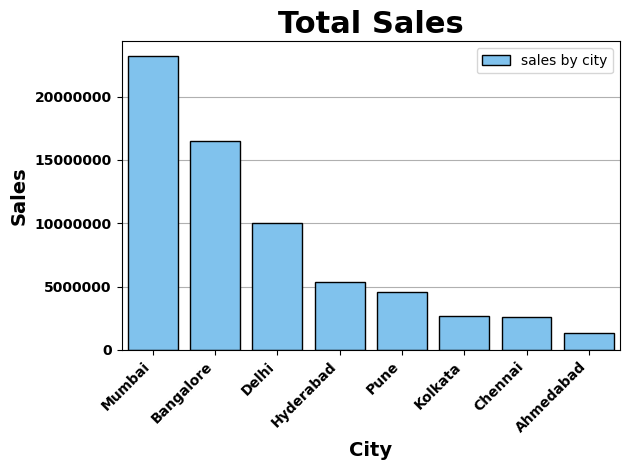

In [ ]:
sns.barplot(x=total_sales_by_city.index, y=total_sales_by_city.values,color="#6EC6FF" ,edgecolor="black",label="sales by city")
plt.title("Total Sales",fontsize="22",fontweight="bold")
plt.xlabel("City",fontsize="14",fontweight="bold",color="black")
plt.ylabel("Sales",fontsize="14",fontweight="bold",color="black")
plt.xticks(rotation=45,ha="right",fontweight="bold")
plt.yticks(fontweight="bold")
plt.ticklabel_format(style="plain",axis="y")
plt.grid(axis="y", linestyle="-", alpha=1)
plt.gca().set_axisbelow(True)
plt.legend(loc="upper right")
plt.tight_layout()



plt.show()



**Top 5 Products by Sales Amount**

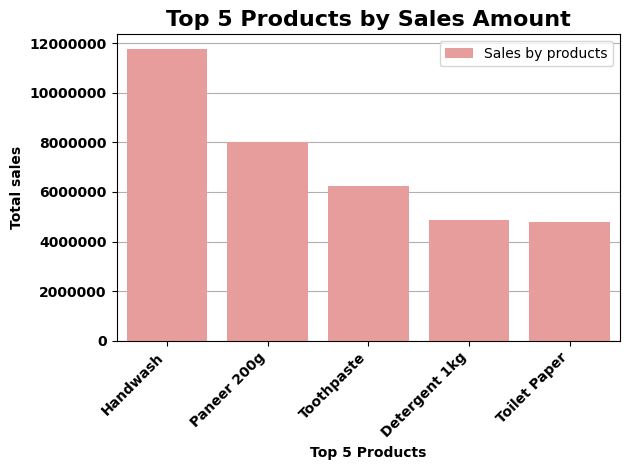

In [ ]:
sns.barplot(x=top_products.index,y=top_products.values,color="#f59090",label="Sales by products")
plt.title("Top 5 Products by Sales Amount",fontweight="bold",fontsize=16)
plt.ylabel("Total sales",fontweight="bold",fontsize=10)
plt.xlabel("Top 5 Products",fontweight="bold")
plt.ticklabel_format(style="plain",axis="y")
plt.xticks(rotation=45,ha="right",fontweight="bold")
plt.yticks(fontweight="bold")
plt.legend(loc="upper right")
plt.grid(axis="y",linestyle="-",alpha=1)
plt.gca().set_axisbelow(True)
plt.tight_layout()


**Sales by Product Category**

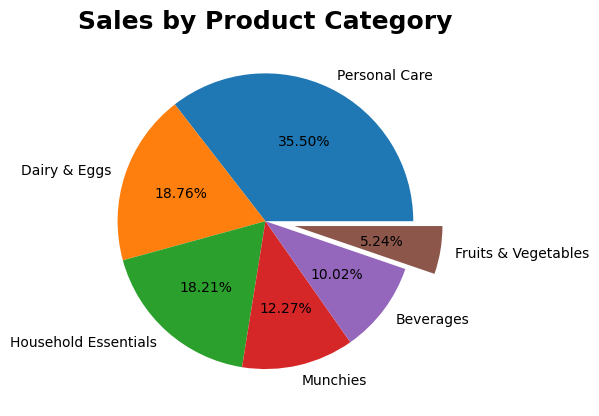

In [ ]:
plt.pie(sales_by_category.values, labels=sales_by_category.index, autopct='%2.2f%%',explode=[0,0,0,0,0,0.2])
plt.title("Sales by Product Category",fontsize=18,fontweight="bold")
plt.show()

**Quantity VS Total Amount**

Text(0, 0.5, 'Total_Amount')

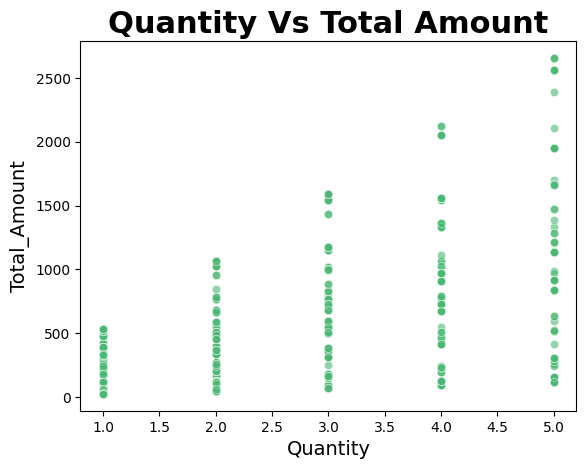

In [ ]:
sns.scatterplot(x="quantity", y="total_amount", data=df.sample(n=5000), alpha=0.6, color="#48b872")
plt.title("Quantity Vs Total Amount",fontsize = 22,fontweight="bold")
plt.xlabel("Quantity",fontsize=14)
plt.ylabel("Total_Amount",fontsize=14)

**Top 5 Products By Quantity Sold**

In [ ]:
top_products_by_qnty_sold  = df.merge(df1,on="product_id")
top_products_by_qnty_sold =top_products_by_qnty_sold.groupby("product_name")["quantity"].sum().nlargest(5)
print(top_products_by_qnty_sold )

product_name
Paneer 200g    35299
Toothpaste     34182
Banana         30357
Handwash       30153
Orange         20526
Name: quantity, dtype: int64


/tmp/ipykernel_462/4176279354.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_by_qnty_sold.index,y=top_products_by_qnty_sold.values,palette="Spectral")


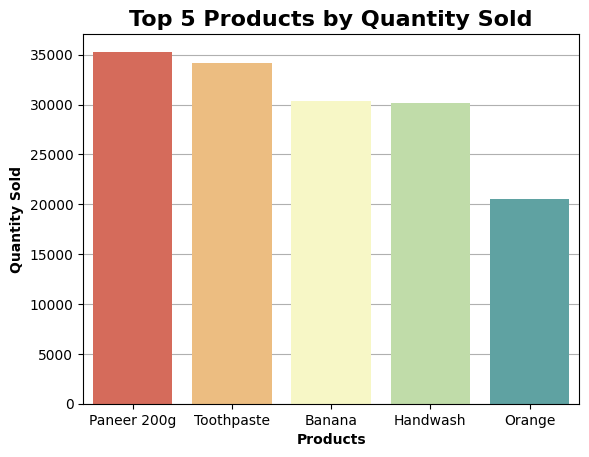

In [ ]:
sns.barplot(x=top_products_by_qnty_sold.index,y=top_products_by_qnty_sold.values,palette="Spectral")
plt.title("Top 5 Products by Quantity Sold",fontsize=16,fontweight="bold")
plt.xlabel("Products",fontweight="bold")
plt.ylabel("Quantity Sold",fontweight="bold")
plt.grid(axis="y",linestyle="-",alpha=1)
plt.gca().set_axisbelow(True)

**Delivery time by City**

/tmp/ipykernel_462/4294920335.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="city",y="delivery_time_mins",data=df,palette="coolwarm")


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Bangalore'),
  Text(1, 0, 'Mumbai'),
  Text(2, 0, 'Hyderabad'),
  Text(3, 0, 'Delhi'),
  Text(4, 0, 'Chennai'),
  Text(5, 0, 'Ahmedabad'),
  Text(6, 0, 'Kolkata'),
  Text(7, 0, 'Pune')])

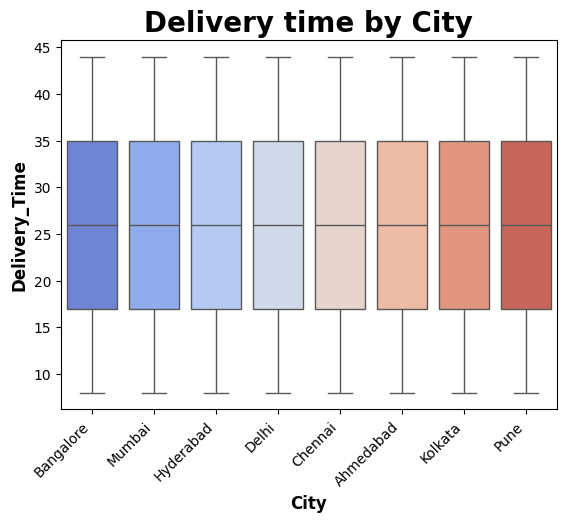

In [ ]:
sns.boxplot(x="city",y="delivery_time_mins",data=df,palette="coolwarm")
plt.title("Delivery time by City",fontsize=20,fontweight="bold")
plt.xlabel("City",fontsize=12,fontweight="bold")
plt.ylabel("Delivery_Time",fontsize=12,fontweight="bold")
plt.xticks(rotation=45,ha="right")


**Distribution of Delivery Status**

/tmp/ipykernel_462/668092335.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="delivery_status",data=df,palette="bright")


Text(0, 0.5, 'Count')

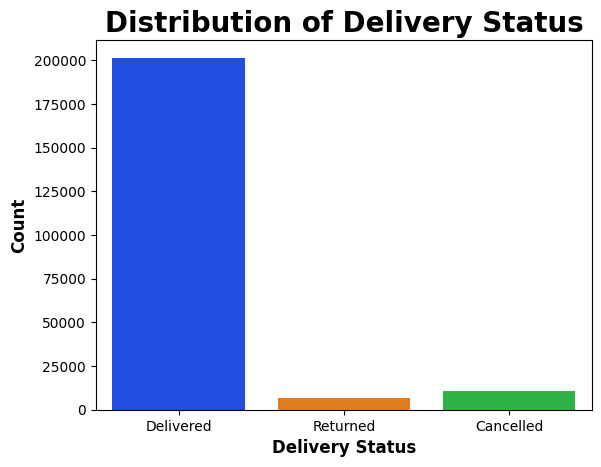

In [ ]:

sns.countplot(x="delivery_status",data=df,palette="bright")
plt.title("Distribution of Delivery Status",fontsize=20,fontweight="bold")
plt.xlabel("Delivery Status",fontsize=12,fontweight="bold")
plt.ylabel("Count",fontsize=12,fontweight="bold")
